# NYC Yellow Taxi — exploratory analysis

Use this notebook after `scripts/download_data.py` to explore `data/raw/yellow_tripdata_2025-01.parquet`.

- Sample columns with `pandas.read_parquet(..., columns=[...])`.
- Plot hourly pickup counts for top zones.
- Compare raw vs cleaned counts using `taxi_demand.cleaning.clean_yellow_taxi_trips`.

In [24]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

sys.path.insert(0, str(src_path))

print("Notebook current folder:", Path.cwd())
print("Project root:", project_root)
print("Src path:", src_path)
print("Src path exists:", src_path.exists())

Notebook current folder: c:\Users\4070TISUPER\Desktop\orie_final\nyc-taxi-demand\notebooks
Project root: c:\Users\4070TISUPER\Desktop\orie_final\nyc-taxi-demand
Src path: c:\Users\4070TISUPER\Desktop\orie_final\nyc-taxi-demand\src
Src path exists: True


In [25]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from taxi_demand.data import load_dataset
from taxi_demand.modeling import (
    time_based_split,
    train_random_forest,
    predict,
    TARGET_COLUMN,
    FEATURE_COLUMNS,
)
from taxi_demand.evaluation import (
    regression_metrics,
    baseline_last_hour,
    evaluate_by_zone,
)

In [26]:
DATA_PATH = Path("../data/processed/hourly_demand_2025_01.parquet")

df = load_dataset(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Dataset shape: (92178, 9)
Columns:
['PULocationID', 'pickup_hour', 'pickup_count', 'hour', 'day_of_week', 'is_weekend', 'lag_1h', 'lag_24h', 'rolling_mean_24h']


,PULocationID,pickup_hour,pickup_count,hour,day_of_week,is_weekend,lag_1h,lag_24h,rolling_mean_24h
0,1,2025-01-01 06:00:00,1,6,2,0,0.0,0.0,0.0
1,1,2025-01-01 13:00:00,1,13,2,0,1.0,0.0,1.0
2,1,2025-01-01 14:00:00,1,14,2,0,1.0,0.0,1.0
3,1,2025-01-01 16:00:00,1,16,2,0,1.0,0.0,1.0
4,1,2025-01-01 18:00:00,1,18,2,0,1.0,0.0,1.0


In [27]:
print("Date range:")
print("Start:", df["pickup_hour"].min())
print("End:", df["pickup_hour"].max())

print("\nNumber of unique pickup zones:", df["PULocationID"].nunique())

print("\nPickup count summary:")
df["pickup_count"].describe()

Date range:
Start: 2024-12-31 20:00:00
End: 2025-02-01 00:00:00

Number of unique pickup zones: 259

Pickup count summary:


count    92178.000000
mean        35.308490
std         72.082743
min          1.000000
25%          1.000000
50%          4.000000
75%         29.000000
max        889.000000
Name: pickup_count, dtype: float64

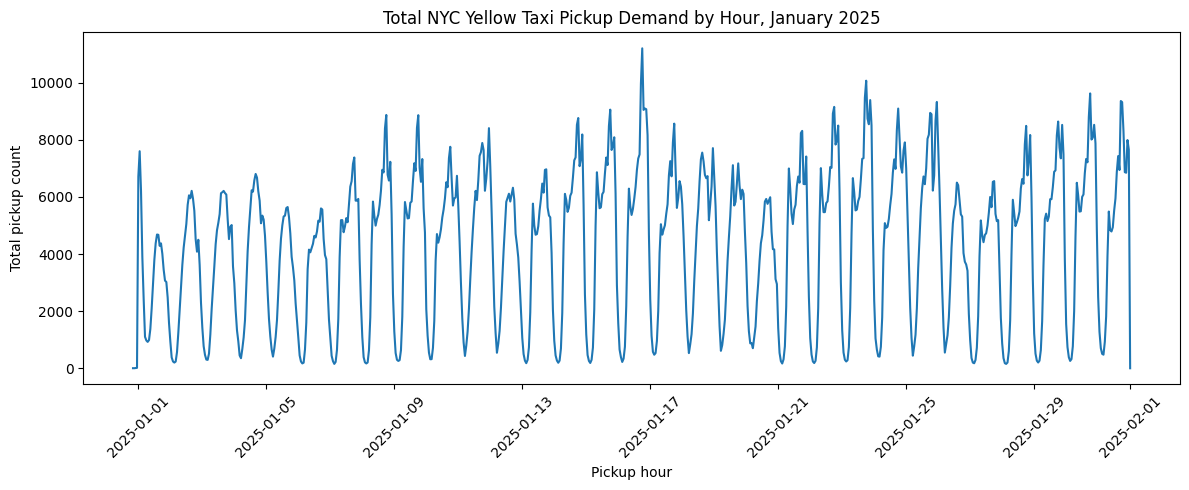

In [28]:
hourly_total = (
    df.groupby("pickup_hour")["pickup_count"]
    .sum()
    .reset_index()
    .sort_values("pickup_hour")
)

plt.figure(figsize=(12, 5))
plt.plot(hourly_total["pickup_hour"], hourly_total["pickup_count"])
plt.title("Total NYC Yellow Taxi Pickup Demand by Hour, January 2025")
plt.xlabel("Pickup hour")
plt.ylabel("Total pickup count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

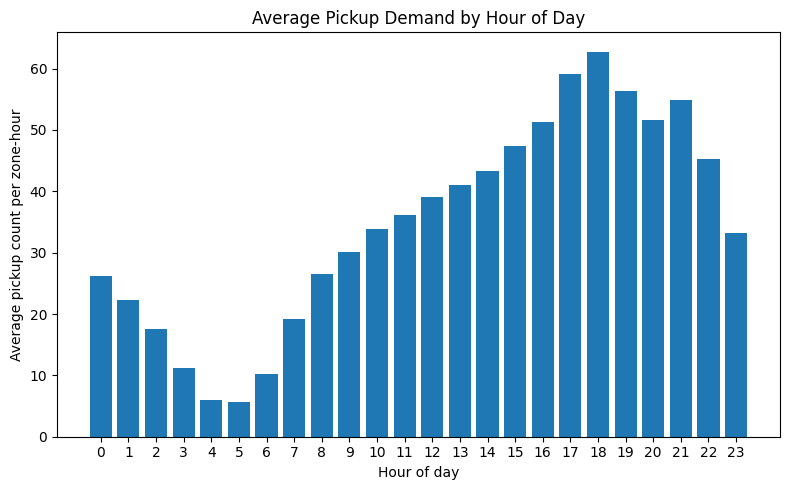

,hour,pickup_count
0,0,26.226295
1,1,22.321710
2,2,17.531590
3,3,11.244835
4,4,6.051957
5,5,5.737077
6,6,10.209109
7,7,19.118483
8,8,26.444598
9,9,30.181798


In [29]:
avg_by_hour = (
    df.groupby("hour")["pickup_count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(avg_by_hour["hour"], avg_by_hour["pickup_count"])
plt.title("Average Pickup Demand by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Average pickup count per zone-hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

avg_by_hour

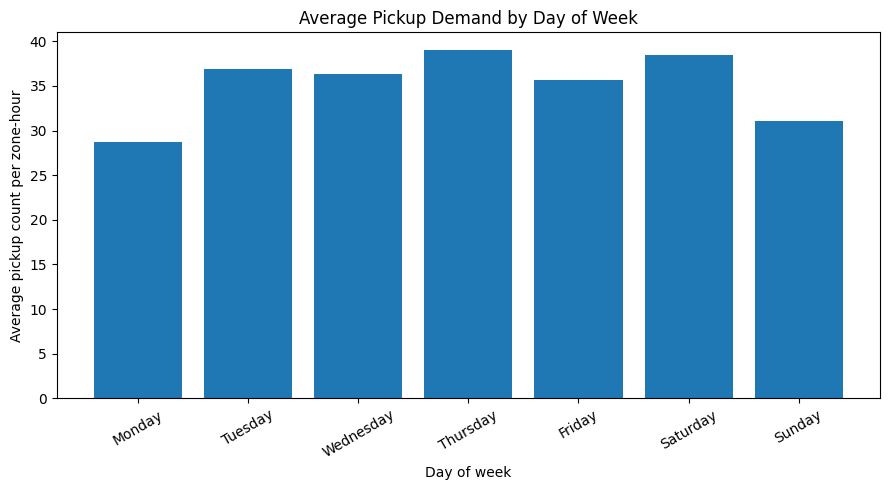

,day_of_week,pickup_count,day_name
0,0,28.693939,Monday
1,1,36.880557,Tuesday
2,2,36.354553,Wednesday
3,3,39.056261,Thursday
4,4,35.639565,Friday
5,5,38.495396,Saturday
6,6,31.068912,Sunday


In [30]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

avg_by_day = (
    df.groupby("day_of_week")["pickup_count"]
    .mean()
    .reset_index()
)

avg_by_day["day_name"] = avg_by_day["day_of_week"].map(day_names)

plt.figure(figsize=(9, 5))
plt.bar(avg_by_day["day_name"], avg_by_day["pickup_count"])
plt.title("Average Pickup Demand by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Average pickup count per zone-hour")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

avg_by_day

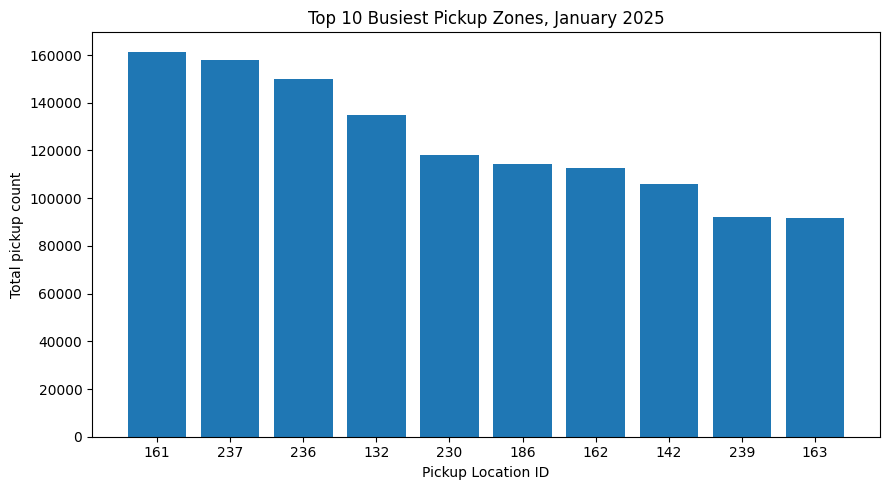

,PULocationID,pickup_count
154,161,161440
230,237,158123
229,236,149869
125,132,134879
223,230,118299
179,186,114159
155,162,112654
135,142,106071
232,239,91923
156,163,91585


In [31]:
top_zones = (
    df.groupby("PULocationID")["pickup_count"]
    .sum()
    .reset_index()
    .sort_values("pickup_count", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
plt.bar(top_zones["PULocationID"].astype(str), top_zones["pickup_count"])
plt.title("Top 10 Busiest Pickup Zones, January 2025")
plt.xlabel("Pickup Location ID")
plt.ylabel("Total pickup count")
plt.tight_layout()
plt.show()

top_zones

In [32]:
train_df, test_df = time_based_split(df, train_frac=0.8)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain time range:")
print(train_df["pickup_hour"].min(), "to", train_df["pickup_hour"].max())

print("\nTest time range:")
print(test_df["pickup_hour"].min(), "to", test_df["pickup_hour"].max())

Train shape: (73742, 9)
Test shape: (18436, 9)

Train time range:
2024-12-31 20:00:00 to 2025-01-26 00:00:00

Test time range:
2025-01-26 00:00:00 to 2025-02-01 00:00:00


In [33]:
model = train_random_forest(train_df)

y_true = test_df[TARGET_COLUMN]
y_pred = predict(model, test_df)
baseline_pred = baseline_last_hour(test_df)

model_metrics = regression_metrics(y_true, y_pred)
baseline_metrics = regression_metrics(y_true, baseline_pred)

print("Random Forest metrics:")
print(model_metrics)

print("\nBaseline metrics:")
print(baseline_metrics)

Random Forest metrics:
{'mae': 6.3887995239645, 'rmse': 15.776191686243267, 'r2': 0.9537589859122801}

Baseline metrics:
{'mae': 9.73486656541549, 'rmse': 23.972999565754147, 'r2': 0.8932254484877332}


In [34]:
metrics_df = pd.DataFrame(
    [
        {"model": "Random Forest", **model_metrics},
        {"model": "Baseline: lag_1h", **baseline_metrics},
    ]
)

metrics_df

,model,mae,rmse,r2
0,Random Forest,6.388800,15.776192,0.953759
1,Baseline: lag_1h,9.734867,23.973000,0.893225


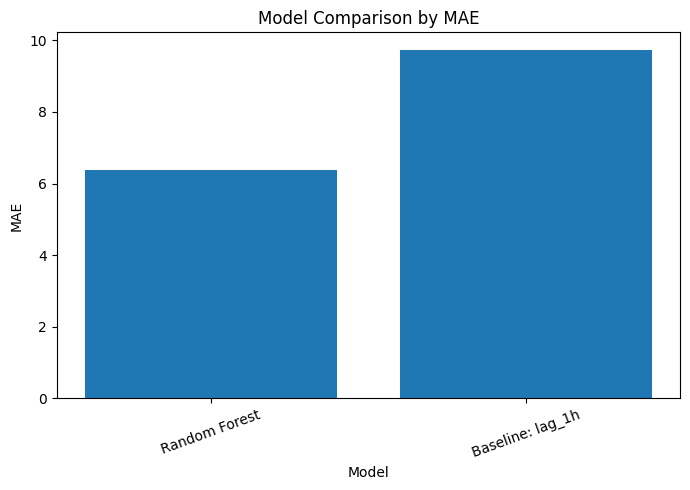

In [35]:
plt.figure(figsize=(7, 5))
plt.bar(metrics_df["model"], metrics_df["mae"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

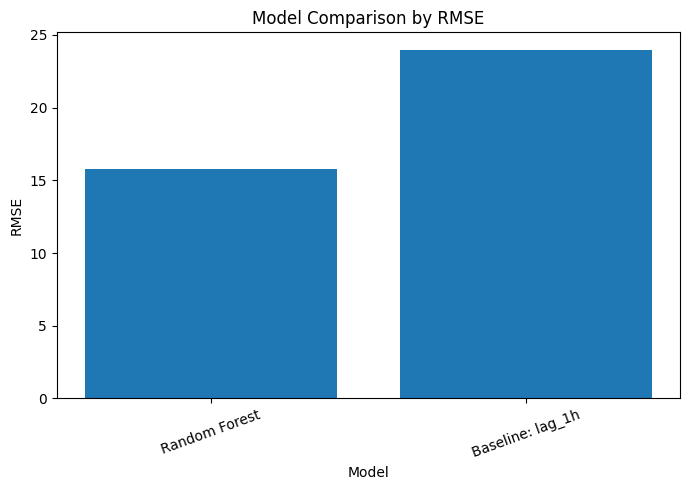

In [36]:
plt.figure(figsize=(7, 5))
plt.bar(metrics_df["model"], metrics_df["rmse"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

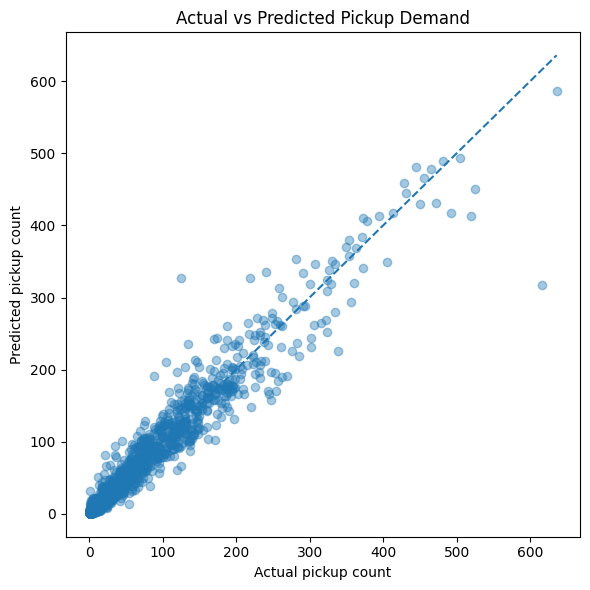

In [37]:
sample_size = min(3000, len(test_df))
sample_idx = np.random.default_rng(42).choice(len(test_df), size=sample_size, replace=False)

y_true_array = y_true.to_numpy()
y_pred_array = np.asarray(y_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_array[sample_idx], y_pred_array[sample_idx], alpha=0.4)
plt.title("Actual vs Predicted Pickup Demand")
plt.xlabel("Actual pickup count")
plt.ylabel("Predicted pickup count")

max_value = max(y_true_array[sample_idx].max(), y_pred_array[sample_idx].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.tight_layout()
plt.show()

Selected zone: 161
Rows: 142


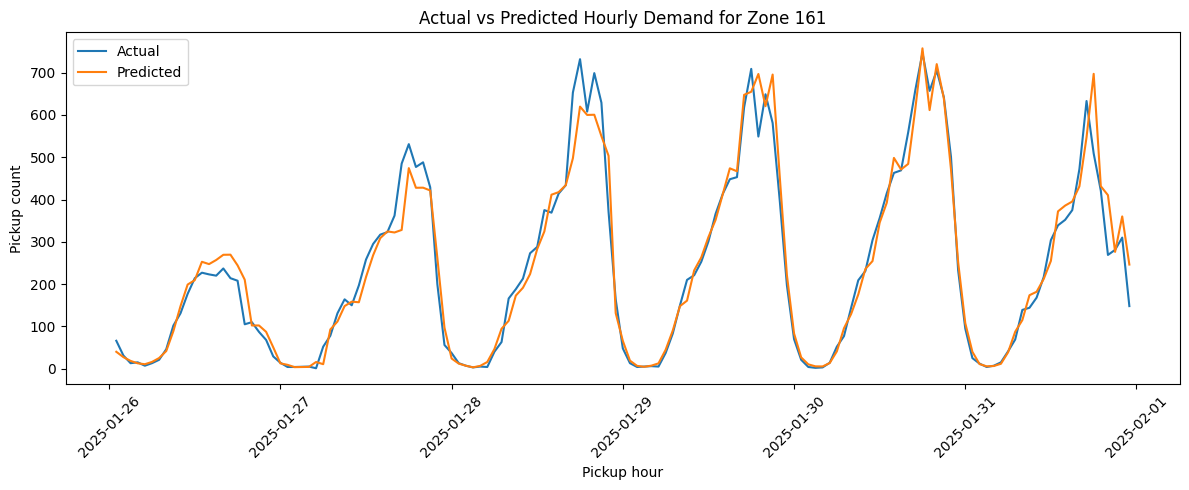

,PULocationID,pickup_hour,pickup_count,hour,day_of_week,is_weekend,lag_1h,lag_24h,rolling_mean_24h,prediction
73870,161,2025-01-26 01:00:00,66,1,6,1,115.0,35.0,179.416667,39.97
73965,161,2025-01-26 02:00:00,31,2,6,1,66.0,17.0,180.708333,27.26
74076,161,2025-01-26 03:00:00,13,3,6,1,31.0,10.0,181.291667,18.41
74193,161,2025-01-26 04:00:00,15,4,6,1,13.0,9.0,181.416667,12.67
74282,161,2025-01-26 05:00:00,7,5,6,1,15.0,7.0,181.666667,10.54


In [38]:
zone_id = int(top_zones.iloc[0]["PULocationID"])

zone_test = test_df[test_df["PULocationID"] == zone_id].copy()
zone_test["prediction"] = predict(model, zone_test)
zone_test = zone_test.sort_values("pickup_hour")

print("Selected zone:", zone_id)
print("Rows:", len(zone_test))

plt.figure(figsize=(12, 5))
plt.plot(zone_test["pickup_hour"], zone_test["pickup_count"], label="Actual")
plt.plot(zone_test["pickup_hour"], zone_test["prediction"], label="Predicted")
plt.title(f"Actual vs Predicted Hourly Demand for Zone {zone_id}")
plt.xlabel("Pickup hour")
plt.ylabel("Pickup count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

zone_test.head()

In [39]:
zone_errors = evaluate_by_zone(test_df, y_pred)

print("Worst 10 zones by MAE:")
display(zone_errors.head(10))

print("Best 10 zones by MAE:")
display(zone_errors.sort_values("mae").head(10))

Worst 10 zones by MAE:


,PULocationID,mae,rmse,r2,n_rows
0,120,46.116667,79.478980,0.000000,3
1,138,31.920000,44.416107,0.703776,131
2,132,31.003007,46.047604,0.837178,143
3,236,30.737214,46.309358,0.922536,140
4,186,29.842986,43.589993,0.778705,144
5,161,29.083028,46.164914,0.952808,142
6,142,28.159930,54.799399,0.757575,143
7,237,26.192553,37.128801,0.952876,141
8,79,23.432639,43.612397,0.891256,144
9,230,21.684685,34.063202,0.926543,143


Best 10 zones by MAE:


,PULocationID,mae,rmse,r2,n_rows
247,156,0.000000,0.000000,NaN,1
246,59,0.010000,0.010000,NaN,1
245,118,0.030000,0.031623,0.0,2
243,30,0.070000,0.070000,NaN,1
244,253,0.070000,0.070000,NaN,1
242,251,0.080000,0.080000,NaN,1
240,214,0.090000,0.090000,NaN,1
241,23,0.090000,0.090000,NaN,1
239,57,0.103333,0.116190,0.0,3
238,46,0.126250,0.192516,0.0,8


In [40]:
zone_errors_filtered = zone_errors[zone_errors["n_rows"] >= 20].copy()

print("Best 10 zones by MAE, among zones with at least 20 test observations:")
display(zone_errors_filtered.sort_values("mae").head(10))

print("Worst 10 zones by MAE, among zones with at least 20 test observations:")
display(zone_errors_filtered.sort_values("mae", ascending=False).head(10))

Best 10 zones by MAE, among zones with at least 20 test observations:


,PULocationID,mae,rmse,r2,n_rows
230,183,0.205000,0.289525,0.013370,32
224,200,0.302732,0.379228,-0.669000,21
221,201,0.310476,0.513281,-0.056224,21
220,178,0.313278,0.375996,-2.540462,24
217,53,0.332333,0.457723,-0.309438,30
216,192,0.336933,0.451964,-0.519878,25
211,203,0.389507,0.604400,-0.061778,46
210,171,0.389754,0.526449,-0.201736,23
209,34,0.390400,0.514914,-0.218460,25
208,126,0.419544,0.567794,-0.187579,38


Worst 10 zones by MAE, among zones with at least 20 test observations:


,PULocationID,mae,rmse,r2,n_rows
1,138,31.920000,44.416107,0.703776,131
2,132,31.003007,46.047604,0.837178,143
3,236,30.737214,46.309358,0.922536,140
4,186,29.842986,43.589993,0.778705,144
5,161,29.083028,46.164914,0.952808,142
6,142,28.159930,54.799399,0.757575,143
7,237,26.192553,37.128801,0.952876,141
8,79,23.432639,43.612397,0.891256,144
9,230,21.684685,34.063202,0.926543,143
10,162,20.142797,31.945240,0.944183,143


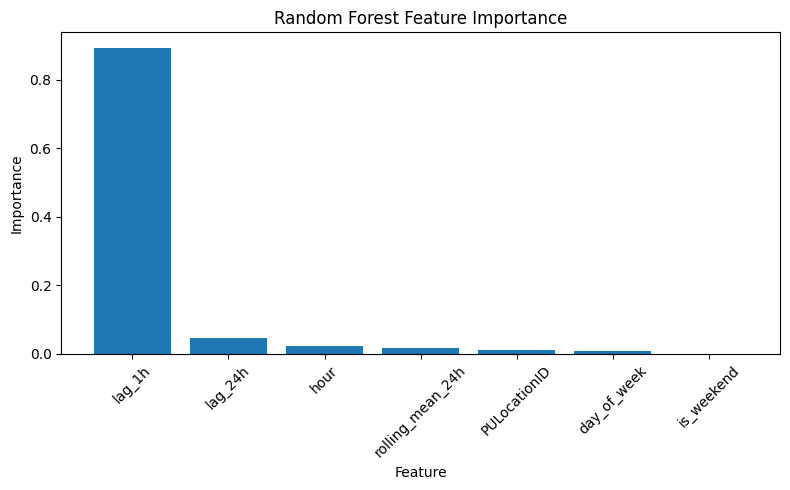

,feature,importance
4,lag_1h,0.893905
5,lag_24h,0.047511
1,hour,0.021834
6,rolling_mean_24h,0.017848
0,PULocationID,0.010628
2,day_of_week,0.007402
3,is_weekend,0.000872


In [41]:
rf = model

feature_importance = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance": rf.feature_importances_,
    }
).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

feature_importance

In [42]:
print("Project Summary")
print("=" * 80)
print(
    f"""
This project predicts hourly NYC Yellow Taxi pickup demand at the taxi-zone level
using January 2025 TLC trip record data.

The raw trip-level data was cleaned and aggregated into a zone-hour dataset with
{len(df):,} observations and {df['PULocationID'].nunique()} unique pickup zones.

The target variable is pickup_count, representing the number of pickups in a
given taxi zone during a given hour.

The Random Forest model uses time features and historical demand features:
{FEATURE_COLUMNS}

On the time-based test set, the Random Forest achieved:
- MAE:  {model_metrics['mae']:.4f}
- RMSE: {model_metrics['rmse']:.4f}
- R2:   {model_metrics['r2']:.4f}

The baseline model, which predicts demand using only the previous hour's demand,
achieved:
- MAE:  {baseline_metrics['mae']:.4f}
- RMSE: {baseline_metrics['rmse']:.4f}
- R2:   {baseline_metrics['r2']:.4f}

Overall, the Random Forest improves on the simple lag-based baseline, suggesting
that combining time features with short-term historical demand helps predict
taxi pickup demand more accurately.
"""
)

Project Summary

This project predicts hourly NYC Yellow Taxi pickup demand at the taxi-zone level
using January 2025 TLC trip record data.

The raw trip-level data was cleaned and aggregated into a zone-hour dataset with
92,178 observations and 259 unique pickup zones.

The target variable is pickup_count, representing the number of pickups in a
given taxi zone during a given hour.

The Random Forest model uses time features and historical demand features:
['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'lag_1h', 'lag_24h', 'rolling_mean_24h']

On the time-based test set, the Random Forest achieved:
- MAE:  6.3888
- RMSE: 15.7762
- R2:   0.9538

The baseline model, which predicts demand using only the previous hour's demand,
achieved:
- MAE:  9.7349
- RMSE: 23.9730
- R2:   0.8932

Overall, the Random Forest improves on the simple lag-based baseline, suggesting
that combining time features with short-term historical demand helps predict
taxi pickup demand more accurately.



## Summary of Findings

This notebook explores hourly NYC Yellow Taxi pickup demand using the January 2025 TLC trip record dataset. After cleaning the raw trip-level data and aggregating it to the taxi-zone-hour level, the processed dataset contains 92,178 observations across 259 pickup zones.

The exploratory analysis shows clear temporal patterns in taxi demand. Average pickup demand is lowest in the early morning hours and rises throughout the day, peaking around the evening commute period. Demand also varies by day of week, with Thursday and Saturday showing relatively high average pickup activity. The busiest pickup zones include zones 161, 237, 236, 132, and 230, which likely correspond to high-traffic commercial, transportation, or central urban areas.

For prediction, the project uses a time-based train/test split. The Random Forest model is compared against a simple baseline that predicts demand using only the previous hour's pickup count. On the test set, the Random Forest achieves a MAE of 6.39, RMSE of 15.78, and R² of 0.954. The baseline achieves a MAE of 9.73, RMSE of 23.97, and R² of 0.893. This means the Random Forest improves both absolute error and squared error relative to the simple lag-based baseline.

The actual-versus-predicted scatter plot and the zone-level time series show that the model captures the overall demand pattern well, especially the recurring daily cycles. Feature importance also shows that `lag_1h` is by far the strongest predictor, suggesting that very recent demand is highly informative for short-term taxi pickup forecasting. Other features, including `lag_24h`, `hour`, and `rolling_mean_24h`, provide additional but smaller predictive value.

Overall, the results suggest that short-term NYC taxi demand is strongly predictable from recent historical demand and time-based features. This supports the project goal of using TLC trip record data to build a reproducible, package-based taxi demand forecasting pipeline.